In [ ]:
import numpy as np
import pandas as pd

from dataclasses import dataclass
from typing import Optional, List, Dict, Any

from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, cross_validate
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingRegressor, BaggingClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier,
    StackingRegressor, StackingClassifier,
    RandomForestRegressor, RandomForestClassifier
)

from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.discriminant_analysis import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    root_mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score
)

from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn import tree
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'pycaret'

# 1. Загрузка данных и их разбиение

In [136]:
cars = pd.read_csv("../data/carsEDA.csv")
smoke = pd.read_csv("../data/smokeEDA.csv")

In [137]:
cars = cars.drop(columns=['Unnamed: 0'])
smoke = smoke.drop(columns=['Unnamed: 0', 'UTC'])

регрессия

In [138]:
Xr = cars.drop(columns=["price_usd"])
yr = cars["price_usd"]

In [139]:
categorical_features = Xr.select_dtypes(include=['object']).columns.tolist()
numeric_features = Xr.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [140]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.2, random_state=42
)

print(Xr_train.shape, Xr_test.shape)


(22703, 32) (5676, 32)


классификация

In [141]:
Xc = smoke.drop(columns=["Fire Alarm"])
yc = smoke["Fire Alarm"].map({True: 1, False: 0})

In [142]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=42, stratify=yc
)

print(Xc_train.shape, Xc_test.shape)

(34172, 10) (8543, 10)


In [143]:
K = 5
cv_reg = KFold(n_splits=K, shuffle=True, random_state=42)
cv_clf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

# 2. Решение задачи регрессии 

In [144]:
def make_preprocessor(df: pd.DataFrame, target_col: str) -> ColumnTransformer:
    X = df.drop(columns=[target_col])

    cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]

    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])

    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )
    return pre


In [145]:
def regression_metrics(y_true, y_pred) -> Dict[str, float]:
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"RMSE": rmse, "MAE": mae, "R2": r2}

In [146]:
def cv_regression(estimator, X, y, cv):
    scoring = {"RMSE": "neg_root_mean_squared_error", "MAE": "neg_mean_absolute_error", "R2": "r2"}
    res = cross_validate(estimator, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return {
        "CV_RMSE": -res["test_RMSE"].mean(),
        "CV_MAE": -res["test_MAE"].mean(),
        "CV_R2": res["test_R2"].mean()
    }

In [147]:
pre_r = make_preprocessor(cars, "price_usd")

models_reg = {
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=42),
    "BaggingRegressor": BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42),
    "StackingRegressor": StackingRegressor(
        estimators=[
            ("dt", DecisionTreeRegressor(random_state=42)),
            ("rf", RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)),
            ("gbr", GradientBoostingRegressor(random_state=42)),
        ],
        final_estimator=Ridge(random_state=42),
        n_jobs=-1
    ),
}

In [148]:
models_reg.update({
    "CatBoostRegressor": CatBoostRegressor(
        iterations=2000, learning_rate=0.05, depth=8,
        loss_function="RMSE", random_seed=42,
        verbose=0
    ),
    "XGBRegressor": XGBRegressor(
        n_estimators=1500, learning_rate=0.05, max_depth=8,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1
    ),
    "LGBMRegressor": LGBMRegressor(
        n_estimators=2000, learning_rate=0.05, num_leaves=63,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1
    ),
})

In [149]:
reg_results = []

for name, est in models_reg.items():
    pipe = Pipeline([("pre", pre_r), ("model", est)])
    pipe.fit(Xr_train, yr_train)

    pred = pipe.predict(Xr_test)
    hold = regression_metrics(yr_test, pred)
    cv = cv_regression(pipe, Xr_train, yr_train, cv=cv_reg)

    reg_results.append({"Model": name, **hold, **cv})

reg_results = pd.DataFrame(reg_results).sort_values("RMSE")
reg_results

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001707 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1041
[LightGBM] [Info] Number of data points in the train set: 22703, number of used features: 32
[LightGBM] [Info] Start training from score 5272.509748


c:\Users\IronSmail\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Model,RMSE,MAE,R2,CV_RMSE,CV_MAE,CV_R2
4,CatBoostRegressor,1112.348005,759.920046,0.928450,1119.729078,764.776463,0.927008
6,LGBMRegressor,1121.798816,767.097992,0.927230,1141.754031,781.266367,0.924097
5,XGBRegressor,1139.933711,781.872784,0.924858,1154.271759,786.254465,0.922432
3,StackingRegressor,1229.088462,834.309106,0.912644,1267.205937,855.813889,0.906522
1,BaggingRegressor,1236.748277,834.707168,0.911552,1279.996636,860.480179,0.904619
2,GradientBoostingRegressor,1374.403581,956.288943,0.890767,1380.563201,959.701496,0.889051
0,DecisionTreeRegressor,1773.150619,1191.092817,0.818190,1838.074050,1230.545070,0.803143


# 3. Решение задачи классификации 

In [152]:
def classification_metrics(y_true, y_pred, y_proba=None) -> Dict[str, float]:
    out = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="binary", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="binary", zero_division=0),
        "F1": f1_score(y_true, y_pred, average="binary", zero_division=0),
    }
    if y_proba is not None and len(np.unique(y_true)) == 2:
        out["ROC_AUC"] = roc_auc_score(y_true, y_proba)
    return out

In [153]:
def cv_classification(estimator, X, y, cv):
    scoring = {"ACC": "accuracy", "F1": "f1", "ROC_AUC": "roc_auc"}
    res = cross_validate(estimator, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return {
        "CV_Accuracy": res["test_ACC"].mean(),
        "CV_F1": res["test_F1"].mean(),
        "CV_ROC_AUC": res["test_ROC_AUC"].mean()
    }

In [154]:
pre_c = make_preprocessor(smoke, "Fire Alarm")

models_clf = {
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=42),
    "BaggingClassifier": BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=42),
    "StackingClassifier": StackingClassifier(
        estimators=[
            ("dt", DecisionTreeClassifier(random_state=42)),
            ("rf", RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)),
            ("gbc", GradientBoostingClassifier(random_state=42)),
        ],
        final_estimator=LogisticRegression(max_iter=2000),
        n_jobs=-1
    ),
}

In [155]:
models_clf.update({
    "CatBoostClassifier": CatBoostClassifier(
        iterations=2000, learning_rate=0.05, depth=8,
        loss_function="Logloss", random_seed=42,
        verbose=0
    ),
    "XGBClassifier": XGBClassifier(
        n_estimators=1500, learning_rate=0.05, max_depth=8,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42, n_jobs=-1
    ),
    "LGBMClassifier": LGBMClassifier(
        n_estimators=2000, learning_rate=0.05, num_leaves=63,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1
    ),
})

In [156]:
clf_results = []

for name, est in models_clf.items():
    pipe = Pipeline([("pre", pre_c), ("model", est)])
    pipe.fit(Xc_train, yc_train)

    pred = pipe.predict(Xc_test)

    proba = None
    if hasattr(pipe, "predict_proba"):
        proba = pipe.predict_proba(Xc_test)[:, 1]

    hold = classification_metrics(yc_test, pred, y_proba=proba)
    cv = cv_classification(pipe, Xc_train, yc_train, cv=cv_clf)

    clf_results.append({"Model": name, **hold, **cv})

clf_results = pd.DataFrame(clf_results).sort_values(["F1", "ROC_AUC"], ascending=False)
clf_results

[LightGBM] [Info] Number of positive: 24582, number of negative: 9590
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001176 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2388
[LightGBM] [Info] Number of data points in the train set: 34172, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.719361 -> initscore=0.941294
[LightGBM] [Info] Start training from score 0.941294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

c:\Users\IronSmail\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\IronSmail\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,CV_Accuracy,CV_F1,CV_ROC_AUC
2,GradientBoostingClassifier,1.000000,1.0,1.000000,1.000000,1.000000,0.999971,0.999980,1.000000
3,StackingClassifier,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,CatBoostClassifier,1.000000,1.0,1.000000,1.000000,1.000000,0.999941,0.999959,1.000000
5,XGBClassifier,1.000000,1.0,1.000000,1.000000,1.000000,0.999941,0.999959,1.000000
6,LGBMClassifier,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,BaggingClassifier,0.999766,1.0,0.999675,0.999837,1.000000,0.999941,0.999959,0.999979
0,DecisionTreeClassifier,0.999766,1.0,0.999675,0.999837,0.999837,0.999883,0.999919,0.999855


# 4. Визуализация

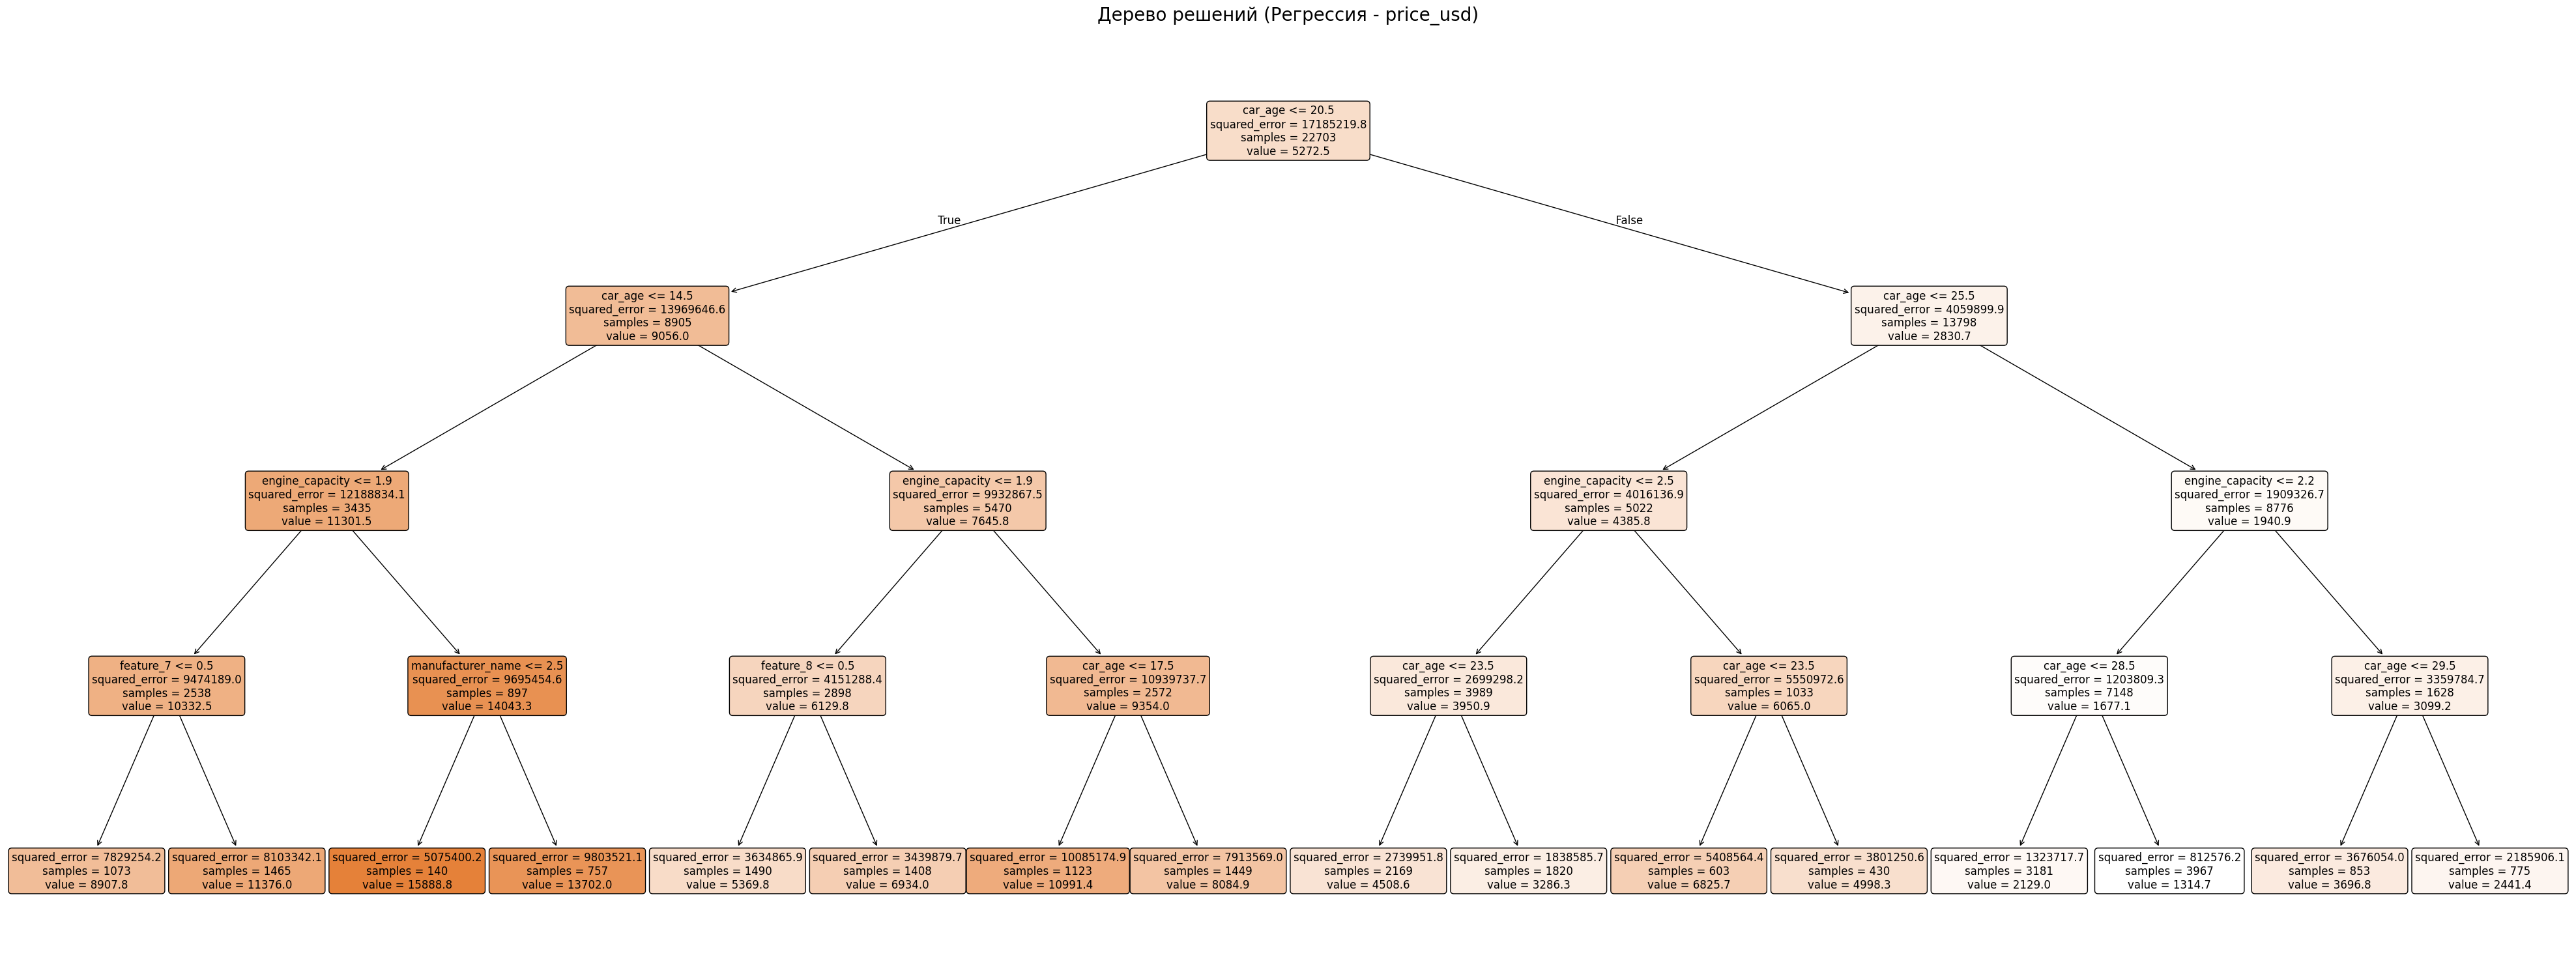

=== Решающие правила (Регрессия) ===
|--- car_age <= 20.50
|   |--- car_age <= 14.50
|   |   |--- engine_capacity <= 1.95
|   |   |   |--- feature_7 <= 0.50
|   |   |   |   |--- value: [8907.76]
|   |   |   |--- feature_7 >  0.50
|   |   |   |   |--- value: [11376.00]
|   |   |--- engine_capacity >  1.95
|   |   |   |--- manufacturer_name <= 2.50
|   |   |   |   |--- value: [15888.80]
|   |   |   |--- manufacturer_name >  2.50
|   |   |   |   |--- value: [13702.00]
|   |--- car_age >  14.50
|   |   |--- engine_capacity <= 1.95
|   |   |   |--- feature_8 <= 0.50
|   |   |   |   |--- value: [5369.84]
|   |   |   |--- feature_8 >  0.50
|   |   |   |   |--- value: [6934.00]
|   |   |--- engine_capacity >  1.95
|   |   |   |--- car_age <= 17.50
|   |   |   |   |--- value: [10991.44]
|   |   |   |--- car_age >  17.50
|   |   |   |   |--- value: [8084.95]
|--- car_age >  20.50
|   |--- car_age <= 25.50
|   |   |--- engine_capacity <= 2.45
|   |   |   |--- car_age <= 23.50
|   |   |   |   |---

In [ ]:
dt_reg = Pipeline([
    ("pre", pre_r),
    ("model", DecisionTreeRegressor(max_depth=4, random_state=42))
])
dt_reg.fit(Xr_train, yr_train)

raw_features_reg = dt_reg.named_steps["pre"].get_feature_names_out()
clean_features_reg = [name.split("__")[-1] for name in raw_features_reg]

fig, ax = plt.subplots(figsize=(40, 15)) 

tree.plot_tree(
    dt_reg.named_steps["model"], 
    feature_names=clean_features_reg,
    filled=True, 
    rounded=True, 
    fontsize=12,
    precision=1, 
    ax=ax
)

plt.title("Дерево решений (Регрессия - price_usd)", fontsize=20, pad=20)
plt.tight_layout()

plt.savefig("tree_regression.svg", format="svg", bbox_inches="tight")
plt.show()

print("=== Решающие правила (Регрессия) ===")
rules_reg = tree.export_text(dt_reg.named_steps["model"], feature_names=clean_features_reg)
print(rules_reg)

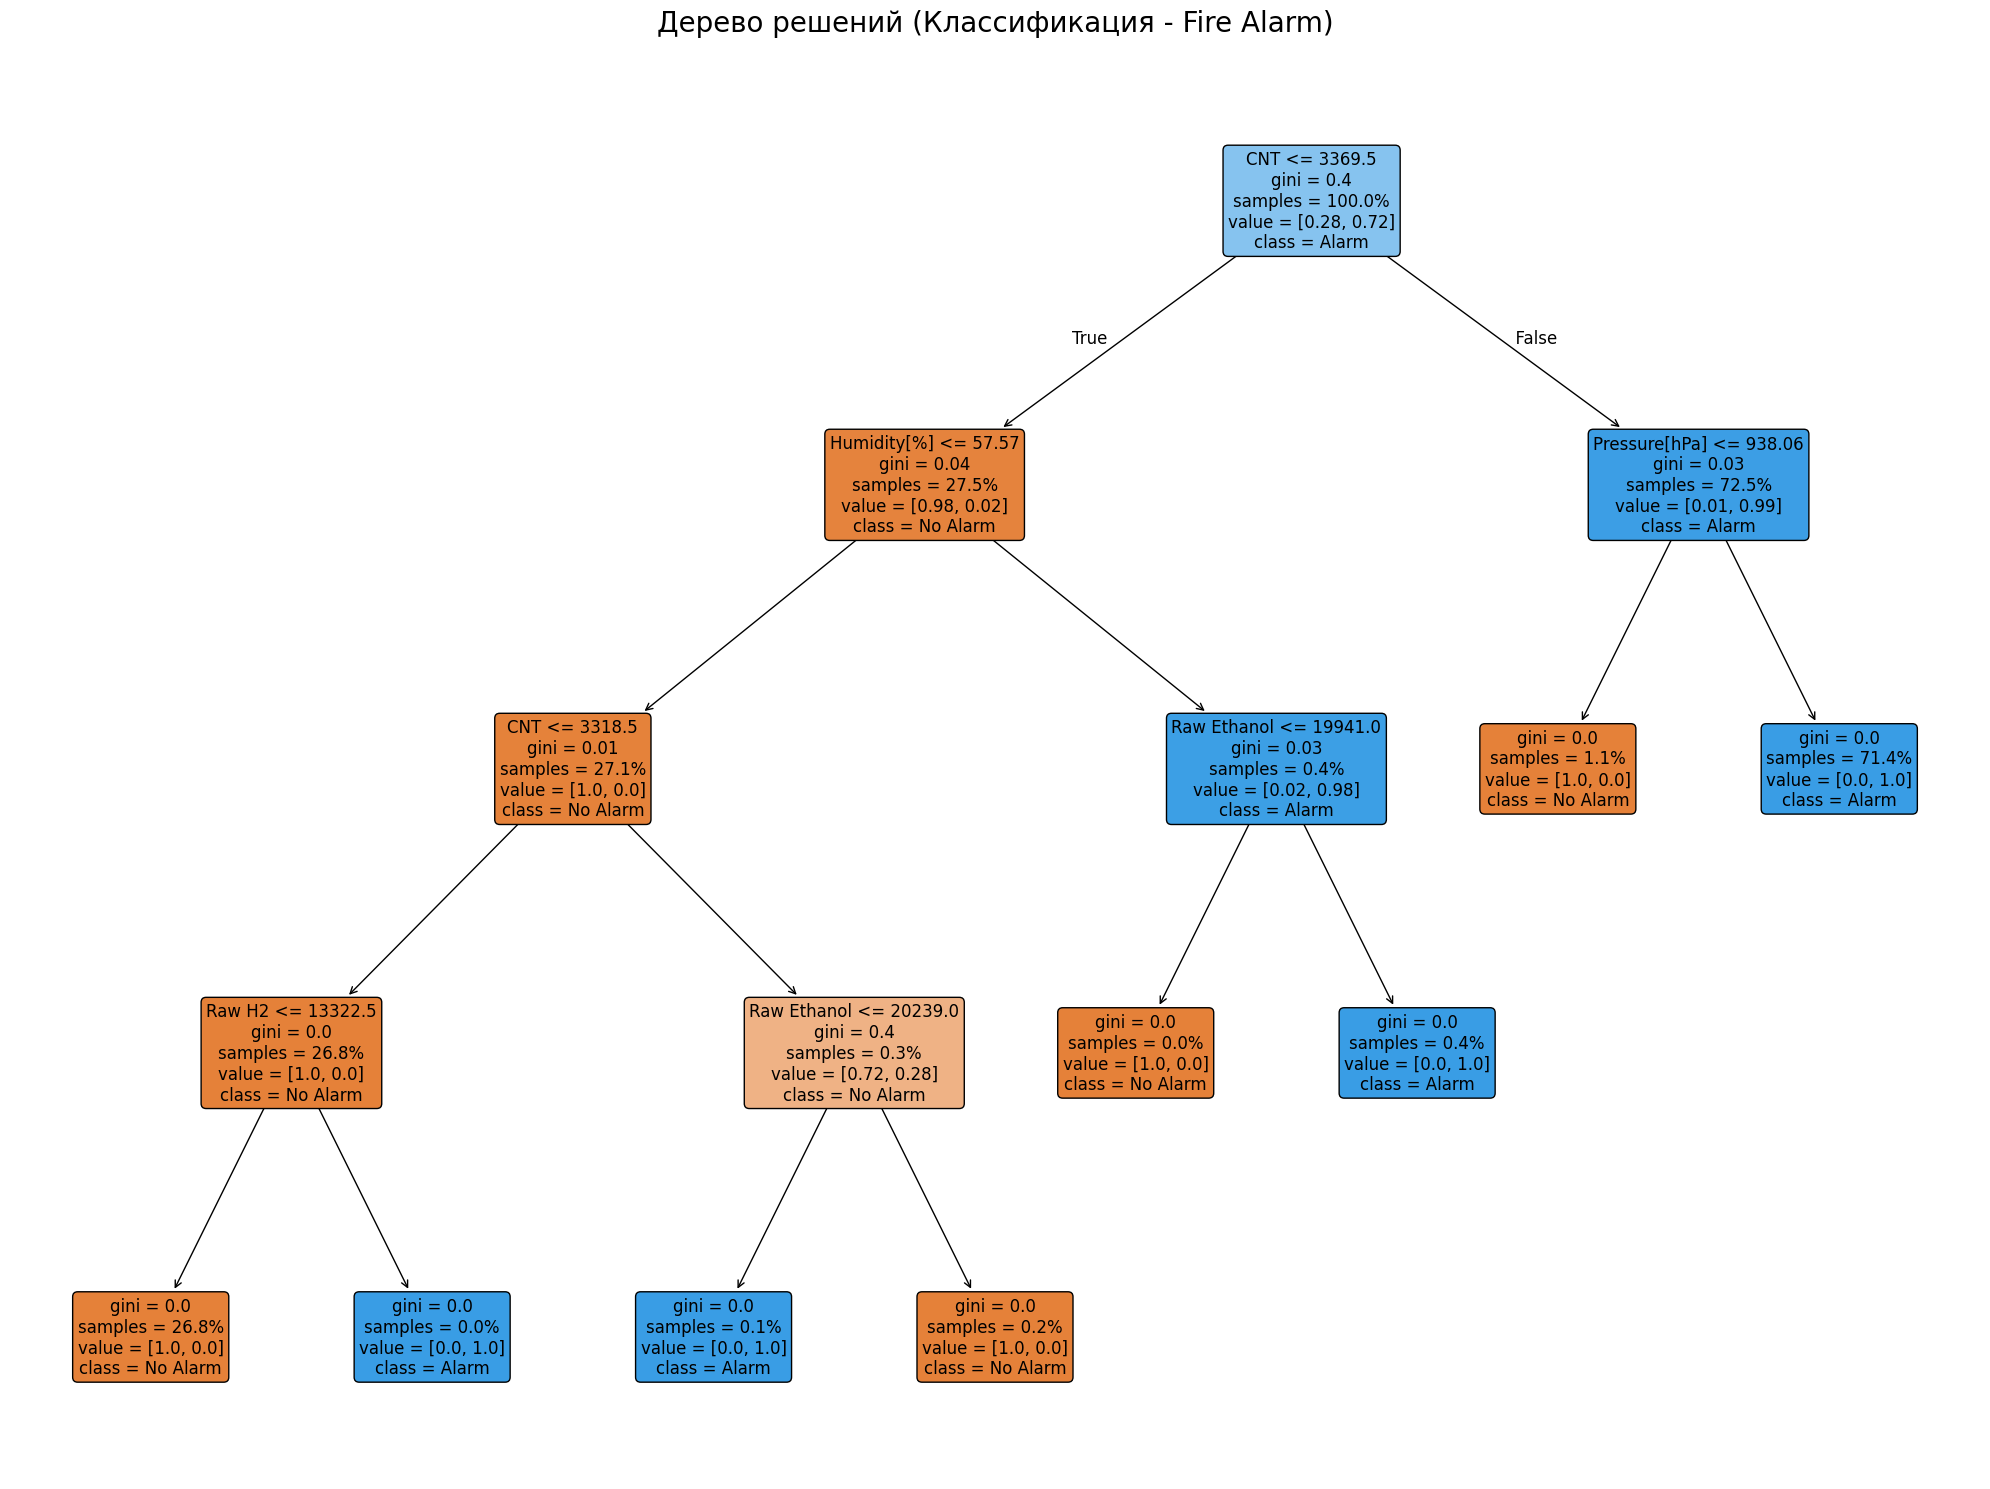

=== Решающие правила (Классификация) ===
|--- CNT <= 3369.50
|   |--- Humidity[%] <= 57.57
|   |   |--- CNT <= 3318.50
|   |   |   |--- Raw H2 <= 13322.50
|   |   |   |   |--- class: 0
|   |   |   |--- Raw H2 >  13322.50
|   |   |   |   |--- class: 1
|   |   |--- CNT >  3318.50
|   |   |   |--- Raw Ethanol <= 20239.00
|   |   |   |   |--- class: 1
|   |   |   |--- Raw Ethanol >  20239.00
|   |   |   |   |--- class: 0
|   |--- Humidity[%] >  57.57
|   |   |--- Raw Ethanol <= 19941.00
|   |   |   |--- class: 0
|   |   |--- Raw Ethanol >  19941.00
|   |   |   |--- class: 1
|--- CNT >  3369.50
|   |--- Pressure[hPa] <= 938.06
|   |   |--- class: 0
|   |--- Pressure[hPa] >  938.06
|   |   |--- class: 1



In [171]:
dt_clf = Pipeline([
    ("pre", pre_c),
    ("model", DecisionTreeClassifier(max_depth=4, random_state=42))
])
dt_clf.fit(Xc_train, yc_train)

# 1. Получаем и ОЧИЩАЕМ названия колонок
raw_features_clf = dt_clf.named_steps["pre"].get_feature_names_out()
clean_features_clf = [name.split("__")[-1] for name in raw_features_clf]

# 2. Огромный холст
fig, ax = plt.subplots(figsize=(20, 15))

# 3. Отрисовка дерева
tree.plot_tree(
    dt_clf.named_steps["model"], 
    feature_names=clean_features_clf,
    class_names=["No Alarm", "Alarm"],
    filled=True, 
    rounded=True, 
    fontsize=12,    
    precision=2,     
    proportion=True, 
    ax=ax
)

plt.title("Дерево решений (Классификация - Fire Alarm)", fontsize=20, pad=20)
plt.tight_layout()

# 4. Сохраняем векторный файл
plt.savefig("tree_classification.svg", format="svg", bbox_inches="tight")
plt.show()

print("=== Решающие правила (Классификация) ===")
rules_clf = tree.export_text(dt_clf.named_steps["model"], feature_names=clean_features_clf)
print(rules_clf)